## The Wiener Filter
---

The Wiener filter is a convolutional matching filter that transforms an input signal $\mathbf x$ to a target signal $\mathbf y$. It does so by minimising:

$$
\min_{\mathbf v} \frac{1}{2} ||\mathbf v * \mathbf x -  \mathbf y||^2,
$$

given by:

$$
\mathbf v = (\mathbf X ^\top \mathbf X )^{-1}\mathbf X \mathbf y,
$$

where $\mathbf X$ is the Toeplitz matrix formulation of $\mathbf x$ that results in the convolution operation. The Wiener filter that matches $\mathbf x$ to $\mathbf y$ is the same that matches the signal $\mathbf y$ to $\mathbf x$ (needs proving), so the filter is equally given by:

$$
\mathbf v = (\mathbf Y ^\top \mathbf Y )^{-1}\mathbf Y \mathbf x.
$$

We then have, in respect to $\mathbf x$, that:


$$
\frac{\partial \mathbf v}{\partial \mathbf x} = (\mathbf Y ^\top \mathbf Y )^{-1}\mathbf Y,
$$

and 

$$
\frac{\partial^2 \mathbf v}{\partial \mathbf x ^2} = \mathbf 0.
$$

If $\mathbf x$ is a function of a model parameterised by $\mathbf \theta$, then by the chain rule:

$$
\frac{\partial \mathbf v}{\partial \mathbf \theta} 
= \frac{\partial \mathbf v}{\partial \mathbf x} \cdot \frac{\partial \mathbf x}{\partial \mathbf \theta} 
= (\mathbf Y ^\top \mathbf Y )^{-1}\mathbf Y \, \mathbf J_{\mathbf x , \mathbf \theta},
$$
where $\mathbf J_{\mathbf x , \mathbf \theta} $ is the Jacobian defined as:

$$
\mathbf J_{\mathbf x,\boldsymbol\theta} 
\coloneqq \frac{\partial \mathbf x}{\partial \boldsymbol\theta} 
= \begin{bmatrix}
\frac{\partial x_1}{\partial \theta_1} & \frac{\partial x_1}{\partial \theta_2} & \cdots & \frac{\partial x_1}{\partial \theta_p} \\[6pt]
\frac{\partial x_2}{\partial \theta_1} & \frac{\partial x_2}{\partial \theta_2} & \cdots & \frac{\partial x_2}{\partial \theta_p} \\[6pt]
\vdots & \vdots & \ddots & \vdots \\[6pt]
\frac{\partial x_n}{\partial \theta_1} & \frac{\partial x_n}{\partial \theta_2} & \cdots & \frac{\partial x_n}{\partial \theta_p}
\end{bmatrix}
\in \mathbb R^{n \times p}.
$$ 

These derivatives are introduced here to be used in later derivations.


## The Wiener Loss Definition
---

The Wiener Loss defined as:
$$
\mathcal{L}_w = \frac{1}{2} || \mathbf{W} \left( \mathbf v - \mathbf \delta \right)|| ^2
$$
for

$$ \mathbf v = \mathbf v  (\mathbf x_{\theta} , \mathbf y )\in \mathbb{R}^n \text{,} \quad \mathbf \delta \in \mathbb{R}^n \text{,} \quad \mathbf{W} \in  \mathbb{R}^{n \times n},$$

where $\mathbf x_{\theta}$ is a signal from a model parameterised by $\mathbf \theta$, is expanded to its normal equation form:

$$
\mathcal{L}_w = \frac{1}{2}  \left( \mathbf v - \mathbf \delta \right) ^\top \mathbf{W}^\top \mathbf{W} \left( \mathbf v - \mathbf \delta \right),
$$

where $\mathbf{W}$ is a whitening matrix that decorrelates the residual $\mathbf{r} = \mathbf{v} - \mathbf{\delta}$ to unit variance from covariance with $\mathbf \Sigma^{-1} = \mathbf{W}^\top \mathbf{W} $. It can therefore be rewritten as:


$$
\mathcal{L}_w = \frac{1}{2}  \mathbf r ^\top \mathbf{\Sigma}^{-1} \mathbf r,
% \label{eq:residual_form}
$$

which computes the distance between the residual vector and a Gaussian distribution with mean $\mu = \mathbf 0$ and covariance $\mathbf \Sigma$, also known as the Mahalanobis distance.

In sum, the Wiener Loss implicitly measures the difference between signals $\mathbf x$ and $\mathbf y $, by measuring the distance between their Wiener filter and a direc delta (convolutional identity).


## Curvature in $\mathbf v$
---

We notice that the residual form of the loss is quadratic in $\mathbf v$, so its gradient is linear:
$$
\mathbf{{\nabla}}_{\mathbf v} \mathcal{L}_w = \mathbf{\Sigma}^{-1}  \mathbf r \frac{\partial \mathbf r}{\partial \mathbf v} = \mathbf{\Sigma}^{-1} (\mathbf v - \mathbf \delta)
$$

and its Hessian a constant:

$$
\mathbf{{\nabla}}^2_{\mathbf v} \mathcal{L}_w = \mathbf{\Sigma}^{-1}
$$

Therefore, the convexity of $\mathcal L_w$ in $\mathbf v$ is purely dictated by the choice of $\mathbf{\Sigma}^{-1}$.

**1) Symmetry**

If $\mathbf{\Sigma}^{-1}$ is not symmetric, the **antisymmetric** part does not contribute to the result since for any vector $\mathbf{r}$ and any skew-symmetric matrix $\mathbf A = -\mathbf A^\top$, we always have $\mathbf{r}^\top \mathbf A \mathbf{r} = 0$. We can isolate the symmetric part of $\mathbf{\Sigma}^{-1}$, without loss of generality, through the Toeplitz decomposition:

$$\mathbf{\Sigma}^{-1} \leftarrow \frac{1}{2}(\mathbf{\Sigma}^{-1} + \mathbf{\Sigma}^{-\top}) $$

**2) Positive Definite**

If $\mathbf{\Sigma}^{-1}$ is positive definite (PD), such that:
$$ \mathbf p^\top \mathbf{\Sigma}^{-1}\mathbf p > 0 \quad \text{for} \quad \forall \, \mathbf p \in \mathbb{R}^n, $$

the quadratic form is strictly convex, and $\mathcal{L}_w$ is a proper weighted least-squares loss, interpretable as a squared Mahalanobis distance; $\mathbf{\Sigma}^{-1}$ is invertible and a single solution exists that satisfies $\mathbf{{\nabla}}_{\mathbf v} \mathcal{L}_w = 0$:
$$
\mathbf v = \mathbf \delta
$$


**3) Indefinite or Negative Definite**

However, if $\mathbf{\Sigma}^{-1}$ is indefinite or negative definite the quadratic form is still valid algebraically, but the loss is no longer convex. In this case,
$$\exists \,\mathbf p \in \mathbb{R}^n \quad \text{such that} \quad \mathbf p^\top \mathbf{\Sigma}^{-1}\mathbf p < 0 ,$$
meaning $\mathcal{L}_w$ can take negative values, and the optimisation problem has no well-defined global minimum. The function is then neither a norm nor a valid distance measure.

**4) Positive Semi-Definite**

If $\mathbf{\Sigma}^{-1}$ is positive semidefinite (PSD), such that:

$$ \mathbf p^\top \mathbf{\Sigma}^{-1}\mathbf p \geq 0 \quad \text{for} \quad \forall \, \mathbf p \in \mathbb{R}^n, $$

 the loss is convex but may be flat in some directions (the Hessian has zero eigenvalues). In such case, many solutions beyond $\mathbf \delta$ exist, $\mathbf{\Sigma}^{-1}$ is not invertible, then $\mathbf \Sigma = \left(\mathbf{\Sigma}^{-1} \right)^{-1}$ would not exist as a proper inverse, and is not a valid covariance matrix.



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [15]:
def get_symmetric_part(A):
    return (A + A.T) / 2

def get_sigma_inv_from_W(W):
    return W.T @ W

def get_sigma_from_W(W):
    sigma_inv = get_sigma_inv_from_W(W)
    try:
        return np.linalg.inv(sigma_inv)
    except np.linalg.LinAlgError:
        return None

def check_definite(A, tol=1e-10):
    # Ensure matrix is numpy array
    A = np.array(A, dtype=float)

    # Get only symmetric part
    A = get_symmetric_part(A)

    # Eigenvalues
    eigvals = np.linalg.eigvalsh(A)  # efficient for symmetric matrices
    
    # Tolerance for numerical precision
    tol = 1e-10
    pos = np.all(eigvals > tol)
    nonneg = np.all(eigvals >= -tol)
    neg = np.all(eigvals < -tol)
    nonpos = np.all(eigvals <= tol)
    
    if pos:
        return "positive_definite"
    elif nonneg:
        return "positive_semidefinite"
    elif neg:
        return "negative_definite"
    elif nonpos:
        return "negative_semidefinite"
    else:
        return "indefinite"

### Looking at A in 2D

For familiarisation, let's look at the generic multi-dimensional quadratic function, centered at zero ($\mathbf b = 0$ and $c = 0$)

$$z = \mathbf x^\top \mathbf A \mathbf x,$$

where in the 2D case $\mathbf x = [x, \, y]$ and we search for the solution $\mathbf x = \mathbf 0$. Below we explore various cases of $\mathbf A$


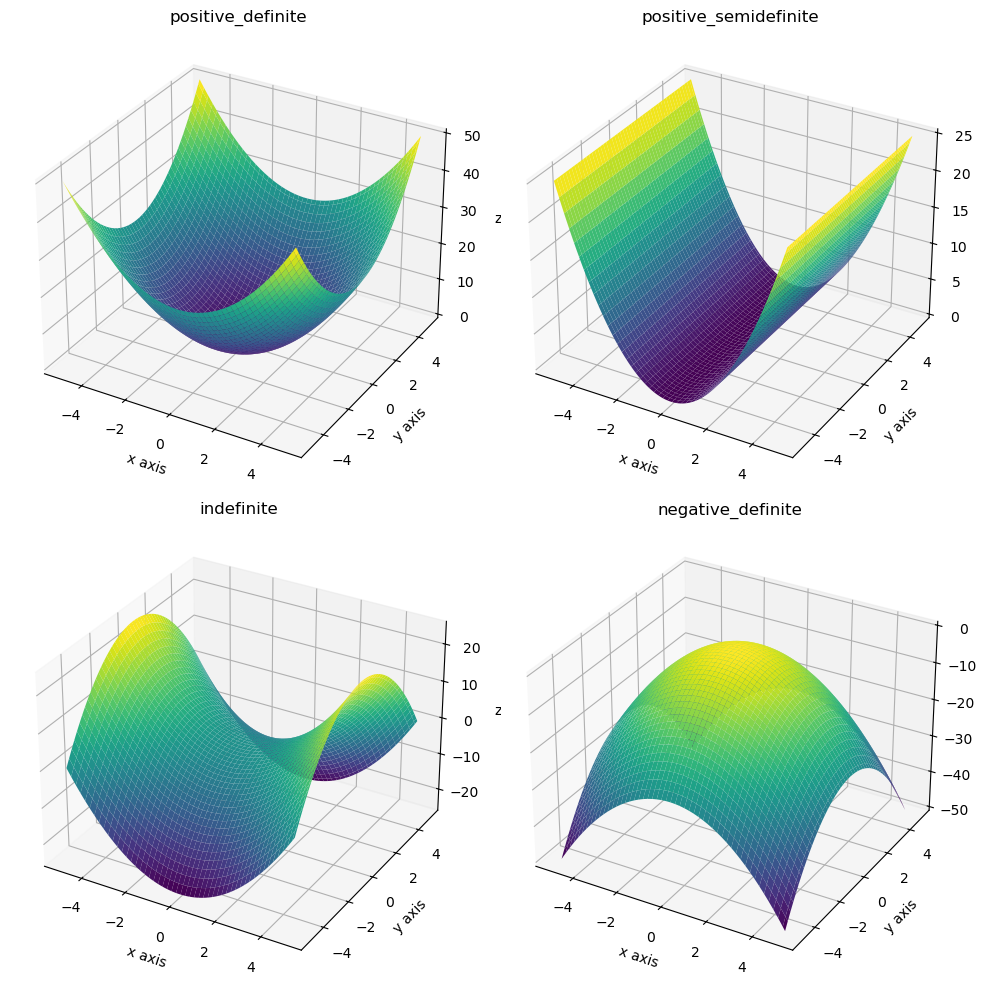

In [16]:
def plot_function_3d(A, b=None, c=None, xlim=(-5, 5), ylim=(-5, 5), num_points=100, ax=None, title=""):
    # Create grid
    x = np.linspace(xlim[0], xlim[1], num_points)
    y = np.linspace(ylim[0], ylim[1], num_points)
    X, Y = np.meshgrid(x, y)

    # Create null b and c if not provided
    n = A.shape[0]
    b = np.zeros(n) if b is None else b
    c = 0 if c is None else c

    # Compute Z values
    Z = np.zeros_like(X)
    for i in range(num_points):
        for j in range(num_points):
            vec = np.array([X[i, j], Y[i, j]])
            Z[i, j] = vec.T @ A @ vec + b.T @ vec + c

    # Plotting
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('x axis')
    ax.set_ylabel('y axis')
    ax.set_zlabel('z')
    ax.set_title(title)
    if ax is None:
        plt.show()


# make 4 subplot axes 2x2
fig, axs = plt.subplots(2, 2, subplot_kw={'projection': '3d'}, figsize=(10, 10))
axs = axs.flatten()

A = np.eye(2)
plot_function_3d(A, ax=axs[0], title=check_definite(A))

# A is positive semidefinite
A = np.array([[1, 0], [0, 0]])
plot_function_3d(A, ax=axs[1], title=check_definite(A))

# A is indefinite
A = np.array([[1, 0], [0, -1]])
plot_function_3d(A, ax=axs[2], title=check_definite(A))
# A is negative definite
A = -np.eye(2)
plot_function_3d(A, ax=axs[3], title=check_definite(A))

plt.tight_layout()
plt.show()

Without positive definiteness, optimisation can be undefined (indefinite and negative definite), or have limited / slow convergence from multiple solutions (positive semidefinite)

### Looking at $W$ and $\Sigma^{-1}$ in $n$-Dimensions

In order to explore and visualise multiple dimensions, we explore the functional value across two random directions. It holds that two random vectors in a high-dimensional space are orthogonal (in our case we deal with middle range dimensions that provide near-orthogonal vectors), providing a good indication, although not perfect, of the function landscape.

We again search for the solution where $\mathbf r = \mathbf 0$

In [17]:
def plot_function_3d_in_projection(A, dir_x, dir_y, b=None, c=None, xlim=(-5, 5), ylim=(-5, 5), num_points=100, ax=None, title=""):
    # Create grid
    x = np.linspace(xlim[0], xlim[1], num_points)
    y = np.linspace(ylim[0], ylim[1], num_points)
    X, Y = np.meshgrid(x, y)

    # Create null b and c if not provided
    n = A.shape[0]
    b = np.zeros(n) if b is None else b
    c = 0 if c is None else c

    # Compute Z values
    Z = np.zeros_like(X)
    for i in range(num_points):
        for j in range(num_points):
            # vec = np.array([X[i, j], Y[i, j]])
            vec = X[i, j] * dir_x + Y[i, j] * dir_y
            Z[i, j] = vec.T @ A @ vec + b.T @ vec + c


    # Plotting
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('X axis projection')
    ax.set_ylabel('Y axis projection')
    ax.set_zlabel('Loss')
    ax.set_title(title)

    if ax is None:
        plt.show()

def plot2d(A, ax=None, title=""):
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots()
        created_fig = True

    ax.imshow(A, cmap='seismic', vmin=-np.max(np.abs(A)), vmax=np.max(np.abs(A)))
    ax.set_title(f"{title}")

    # add colorbar to ax
    plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
    

    if created_fig:
        plt.show()

def plot_example(W, dir_x, dir_y):
    Sinv = get_sigma_inv_from_W(W)
    S = get_sigma_from_W(W)
    # plt.imshow(Sinv, cmap='seismic', vmin=-np.max(np.abs(Sinv)), vmax=np.max(np.abs(Sinv)))
    # plt.show()

    # Create figures
    fig = plt.figure( figsize=(15, 5))  
    ax1 = fig.add_subplot(1, 4, 1)  # add the 1st subplot
    ax2 = fig.add_subplot(1, 4, 2)  # add the 2nd subplot
    ax3 = fig.add_subplot(1, 4, 3)  # add the 3rd subplot
    ax4 = fig.add_subplot(1, 4, 4, projection='3d')  # add the 4th subplot as 3D
    axs = [ax1, ax2, ax3, ax4]

    plot2d(W, ax=axs[0], title=r"$W$ (" + check_definite(W) + ")")
    plot2d(Sinv, ax=axs[1], title=r"$\Sigma^{-1} = W^\top W$ (" + check_definite(Sinv) + ")")
    if S is None:
        S = np.zeros_like(Sinv)  # to visualize singular case
        S_pd = "singular"
    else:
        S_pd = check_definite(S)
    plot2d(S, ax=axs[2], title=r"$\Sigma = (W^\top W)^{-1}$ (" + S_pd + ")")
    plot_function_3d_in_projection(Sinv, dir_x, dir_y, ax=axs[3], xlim=(-5, 5), ylim=(-5, 5), title=r"$z = \mathbf{r}^\top \mathbf{\Sigma^{-1}} \mathbf{r}$ ")
    plt.tight_layout()
    plt.show()

Now the random directions

In [18]:
n = 16*16

# random direction in R^n
np.random.seed(0)
dir_x = np.random.randn(n)
dir_y = np.random.randn(n)

# move to unit vectors
dir_x /= np.linalg.norm(dir_x)
dir_y /= np.linalg.norm(dir_y)

# check angle between dir_x and dir_y
angle = np.arccos(np.clip(np.dot(dir_x, dir_y), -1.0, 1.0))
print(f"Angle between dir_x and dir_y: {np.degrees(angle)} degrees")

Angle between dir_x and dir_y: 91.6632786537102 degrees


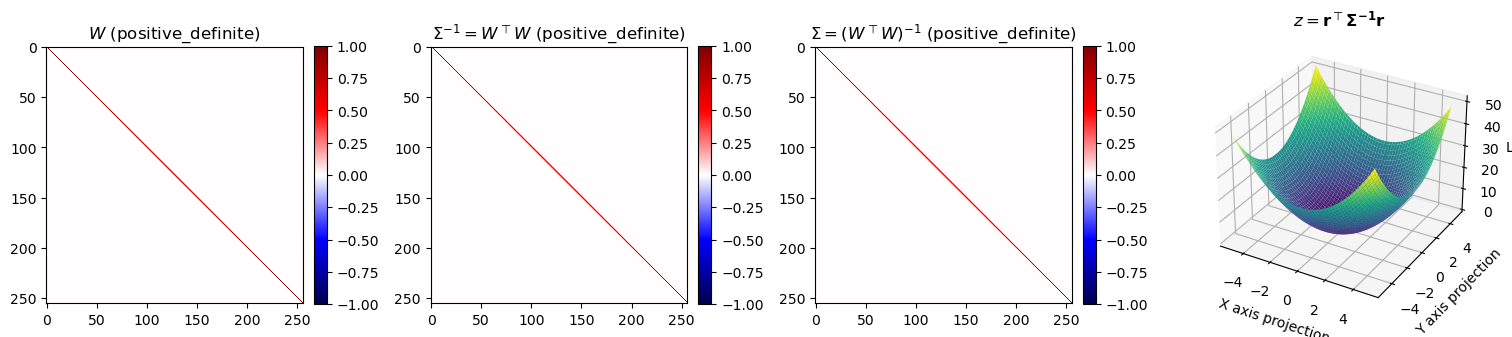

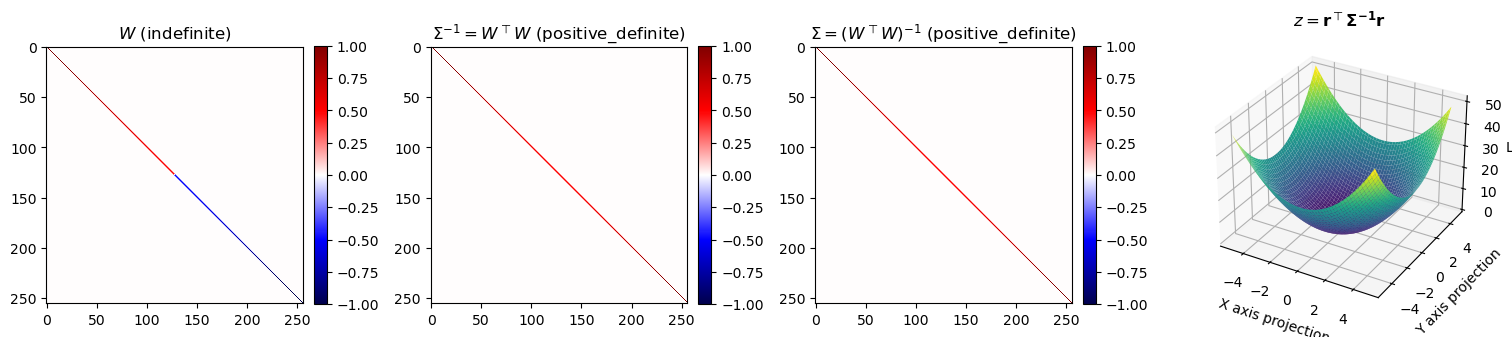

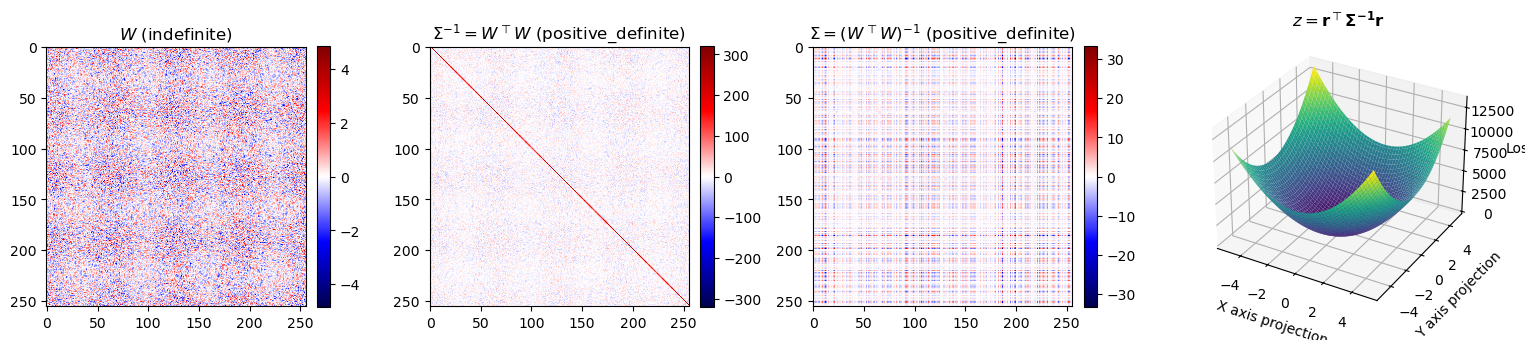

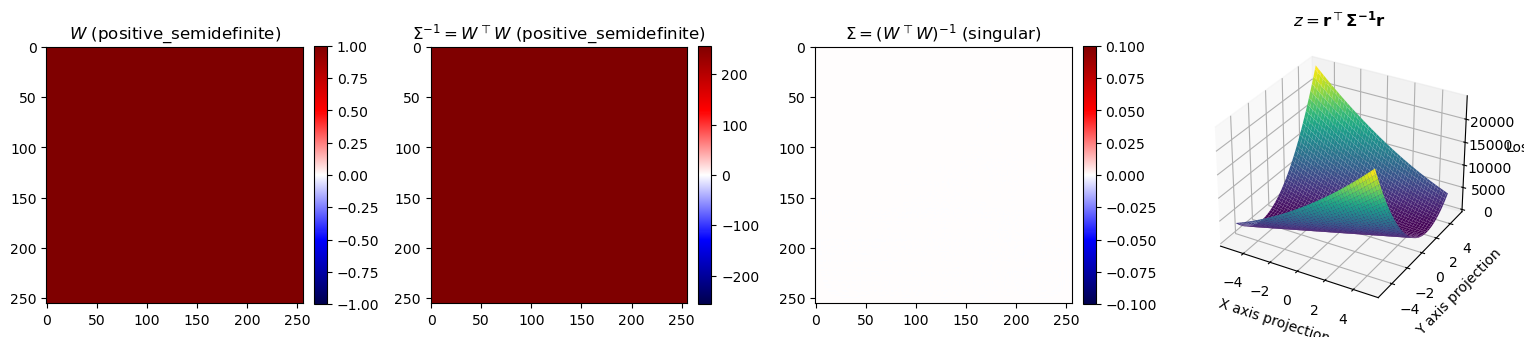

In [19]:
# positive definite example
W = np.eye(n)
plot_example(W, dir_x, dir_y)

# indefinite example
W = np.diag(np.concatenate([np.ones(n//2), -np.ones(n//2)]))
plot_example(W, dir_x, dir_y)


# random example
W = np.random.randn(n, n)
plot_example(W, dir_x, dir_y)

# positive-semidefinite example
W = np.ones((n, n))
plot_example(W, dir_x, dir_y)

### Looking at Penalty Functions

The above derivation and interpretation hold when $\mathbf W$ operates on the residuals as a matrix-vector multiplication.

However, in current form we apply $\mathbf W$ as a **penalty matrix**, $\mathbf T$ through the Hadamard product. Instead we have:

$$
\mathcal{L}_w = \frac{1}{2} || \mathbf{T} \circ \left( \mathbf v - \mathbf \delta \right)|| ^2.
$$

This formulation directly penalises residuals at different lags, which makes it more interpretable and avoiding the computational costs of matrix-vector multiplications with $\mathbf W$. The choice of $\mathbf T$ is arbritary, making it a hyperparameter.

This formulation also forces $\mathbf T$ to take the same form and shape as $\mathbf v$ and $\mathbf \delta$. In the 1D case, all elements  $ \mathbf{T}$, $\mathbf v $, and $ \mathbf \delta $ and vectors. The matrix $\mathbf W$ derived from $\mathbf T$ that computes the same objective, without loss of generality is given by the diagonal matrix whose entries are the entries of $\mathbf T$:
$$\mathbf{W} = \operatorname{diag}\!\big(\mathbf{T}\big)$$

where $\operatorname{diag}(\cdot)$ builds a diagonal matrix from that vector.

More explicitly if:

$$\mathbf{T} =
\begin{bmatrix}
t_{11} \\ t_{21} \\ t_{12} \\ t_{22}
\end{bmatrix},$$

then

$$
\mathbf{W} =
\begin{bmatrix}
t_{11} & 0 & 0 & 0 \\
0 & t_{21} & 0 & 0 \\
0 & 0 & t_{12} & 0 \\
0 & 0 & 0 & t_{22}
\end{bmatrix},$$

and it is clear that

$$
\mathbf{W}\mathbf{r} =   \mathbf{T} \circ \mathbf{r} = 
\begin{bmatrix}
t_{11} r_1 \\ t_{21} r_2 \\ t_{12} r_3 \\ t_{22} r_4
\end{bmatrix}.
$$

The above is also true when $\mathbf v$ and $\mathbf \delta$ are multidimensional (e.g. images or volumes), as long as $\mathbf T$ is of the same size and dimensionality. In such case, equivalent operations are obtained through vectorisation. For instance, a 2D signal requires:


$$\mathbf{T} =
\begin{bmatrix}
t_{11} & t_{12} \\
t_{21} & t_{22}
\end{bmatrix},$$

and $\mathbf W$ is constructed via


$$\mathbf{W} = \operatorname{diag}\!\big(\mathrm{vec}(\mathbf{T})\big)$$

then

$$\mathrm{vec}(\mathbf{T}) =
\begin{bmatrix}
t_{11} \\ t_{21} \\ t_{12} \\ t_{22}
\end{bmatrix},
\qquad
\mathbf{W} =
\begin{bmatrix}
t_{11} & 0 & 0 & 0 \\
0 & t_{21} & 0 & 0 \\
0 & 0 & t_{12} & 0 \\
0 & 0 & 0 & t_{22}
\end{bmatrix},$$

and the objective evaluation also operates in the vectorised space:

$$
\mathcal{L}_w = \frac{1}{2} || \mathbf{W} \, \mathrm{vec}(\mathbf r)|| ^2.
$$

Now that we have established the equivalence of such operations, let's look at what particular penalty functions mean for convexity. 

First, we need a function that constructs $\mathbf W$ from $\mathbf T$:

In [20]:
def get_W_from_T(T):
    return np.diag(T.flatten())

For any penalty matrix $\mathbf W$ is a diagonal matrix, and the operation $\mathbf\Sigma^{-1} = \mathbf W^\top \mathbf W$ will always be symmetric and contain non-negative entries.

This means that $\mathbf\Sigma^{-1}$ will always be at least positive-semi definite, and at least one solution will exist. This is confirmed by the intuition that the solution $\mathbf v = \mathbf \delta$ will always minimise the function, regardless of $\mathbf W$.

So we turn our attention to the cases where $\mathbf\Sigma^{-1}$ is not positive-definite, and many other solutions may also satisfy the minimisation of $\mathcal L_w$.

##### Random Penalty

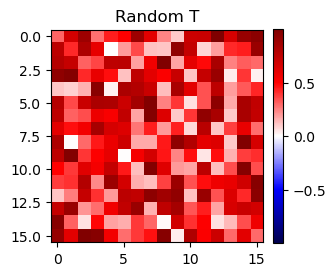

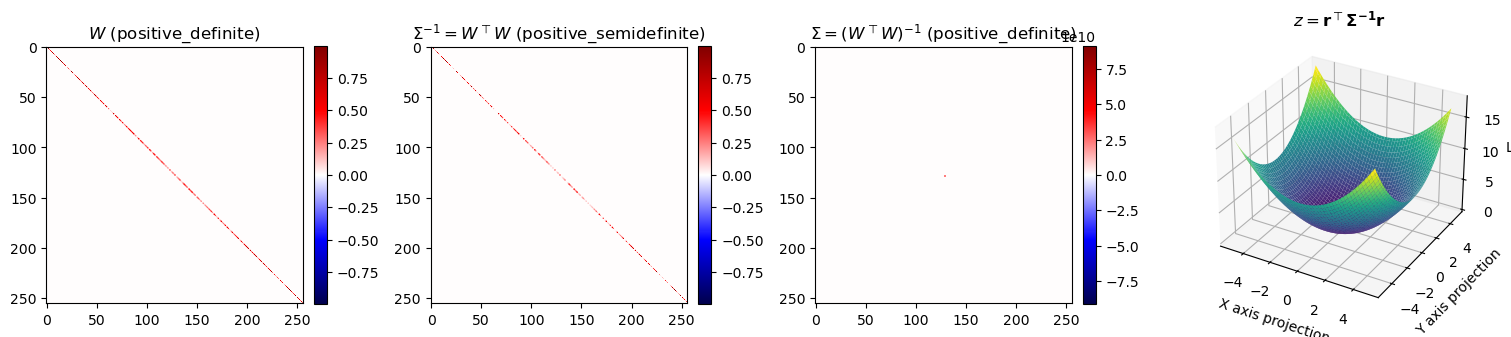

In [21]:
# random T example
T = np.random.rand(np.sqrt(n).astype(int), np.sqrt(n).astype(int))
fig, ax = plt.subplots(1, 1, figsize=(3,3))
plot2d(T, ax=ax,title="Random T")

W = get_W_from_T(T)
plot_example(W, dir_x, dir_y)

##### Gaussian Penalties

In [22]:
def gaussian_penalty(size, std=1.0):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    T = np.exp(-(X**2 + Y**2) / (2 * std**2))
    return T

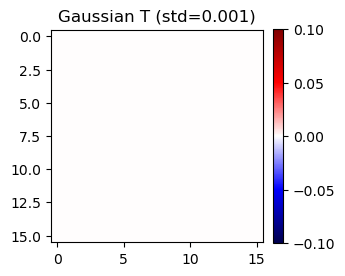

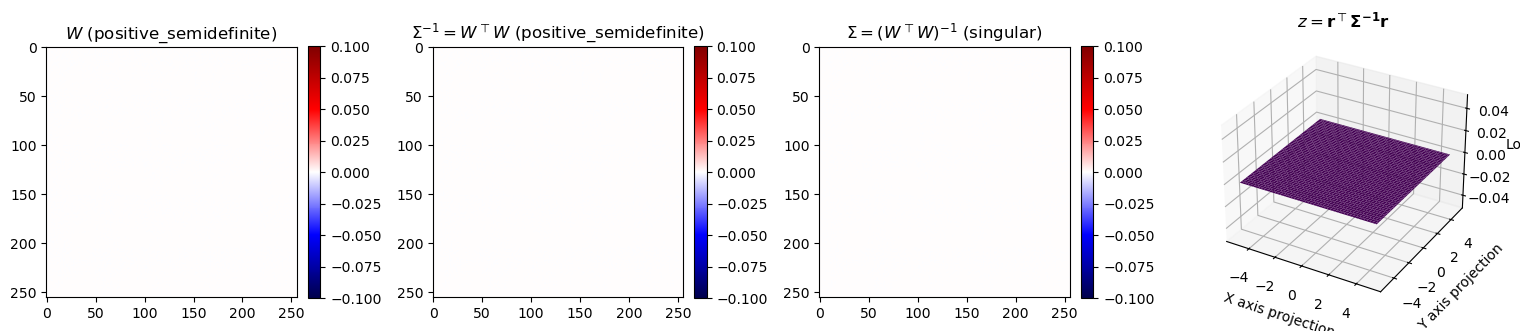

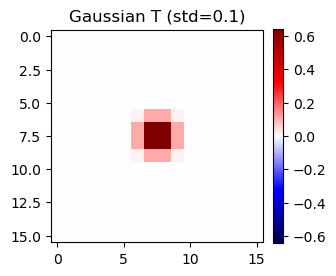

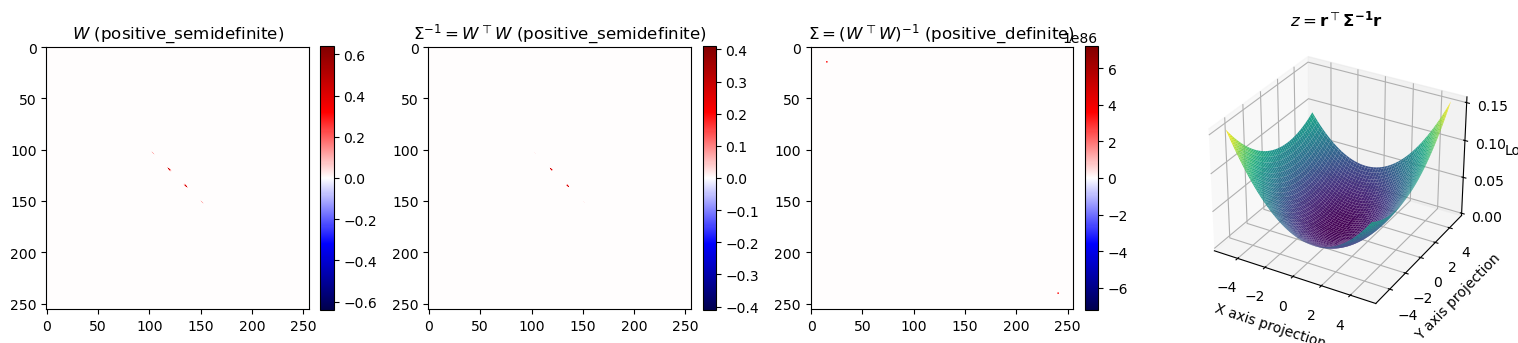

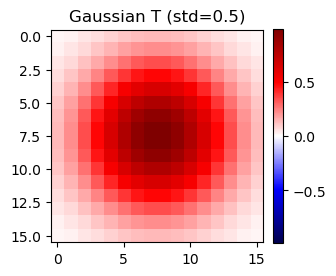

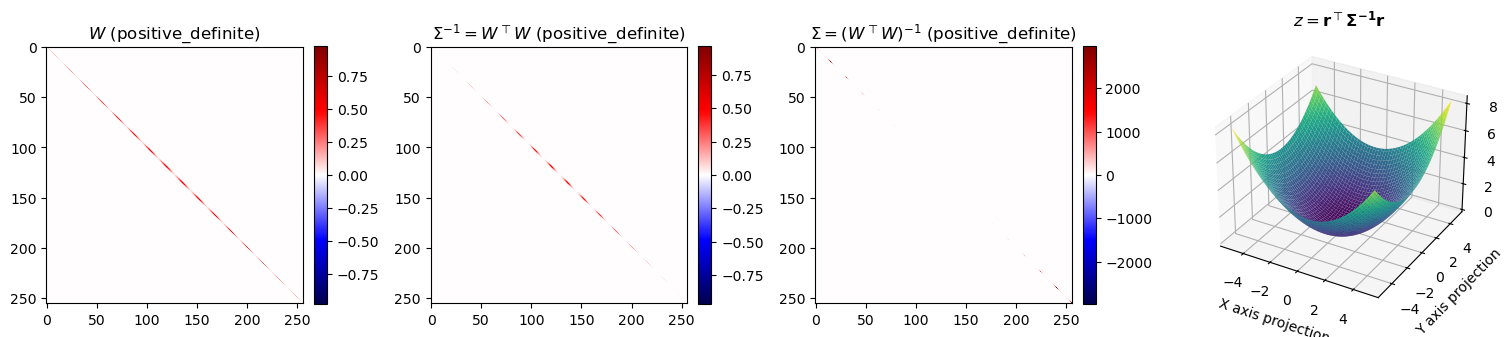

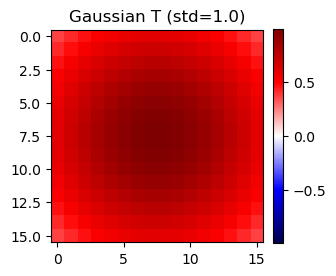

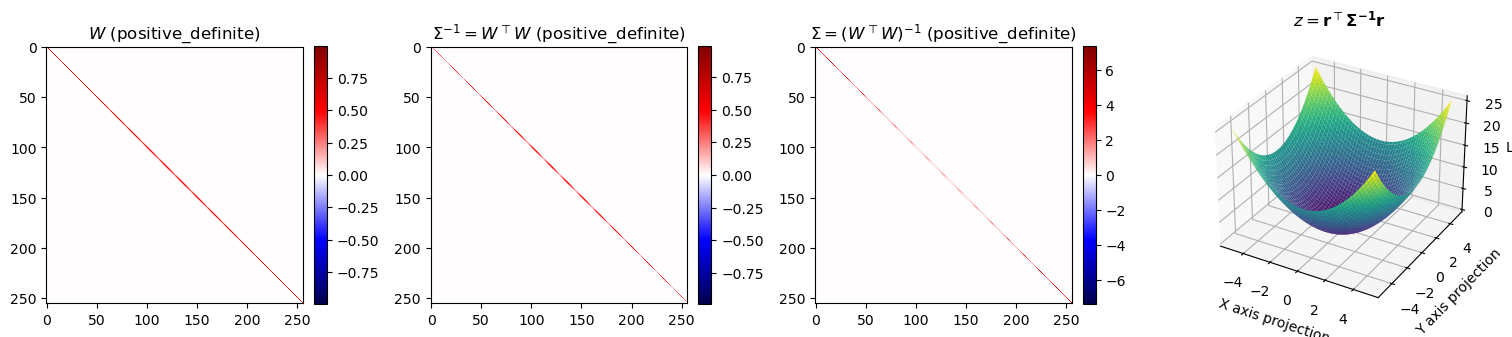

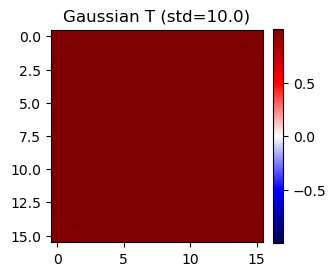

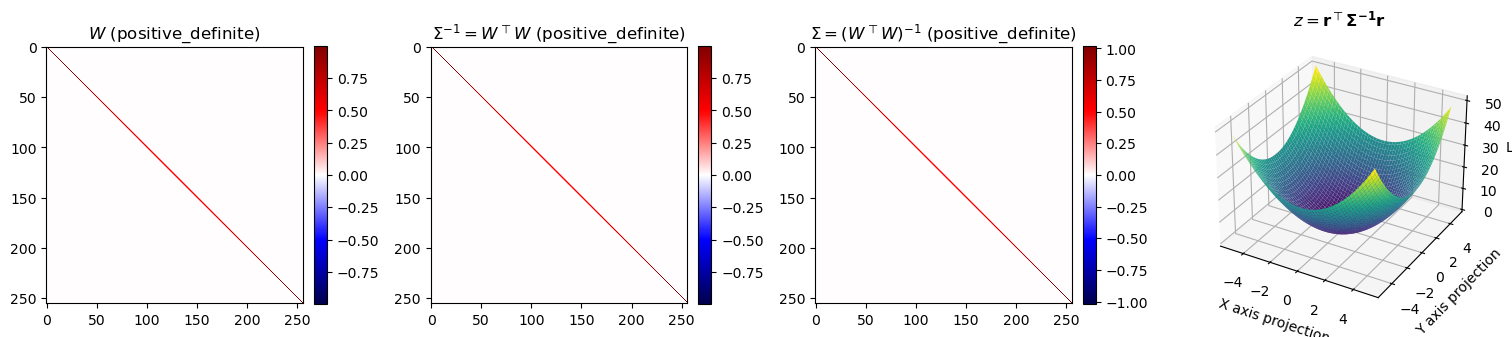

In [23]:
# T is a 2D gaussian function with mean 0 and std 0.1
condition_number = []
stds = [1e-3, 0.1, 0.5, 1.0, 10.]
for std in stds:
    T = gaussian_penalty(int(np.sqrt(n)), std=std)

    fig, ax = plt.subplots(1, 1, figsize=(3,3))
    plot2d(T, ax=ax,title=f"Gaussian T (std={std})")

    W = get_W_from_T(T)
    Sinv = get_sigma_inv_from_W(W)
    condition_number.append(np.linalg.cond(Sinv))
    plot_example(W, dir_x, dir_y)

ValueError: x and y must have same first dimension, but have shapes (5,) and (4,)

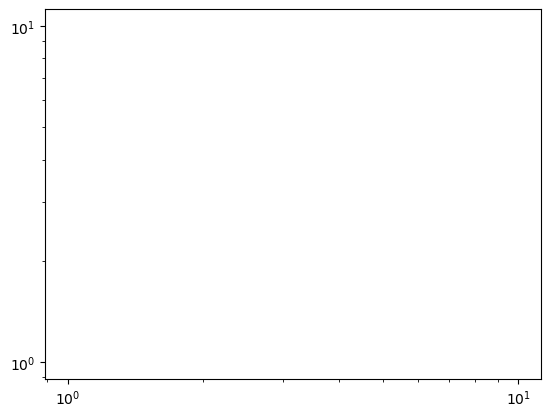

In [29]:
plt.loglog(stds, condition_number)
plt.xlabel("Gaussian std")
plt.ylabel(r"Condition number of $\Sigma^{-1}$")
plt.title("Condition number vs Gaussian std")
plt.grid()
plt.show()

plt.loglog(stds[3:], condition_number[3:])
plt.xlabel("Gaussian std")
plt.ylabel(r"Condition number of $\Sigma^{-1}$")
plt.title("Condition number vs Gaussian std (zoomed in)")
plt.grid()
plt.show()


#### Laplace Penalties

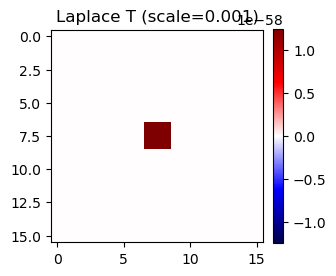

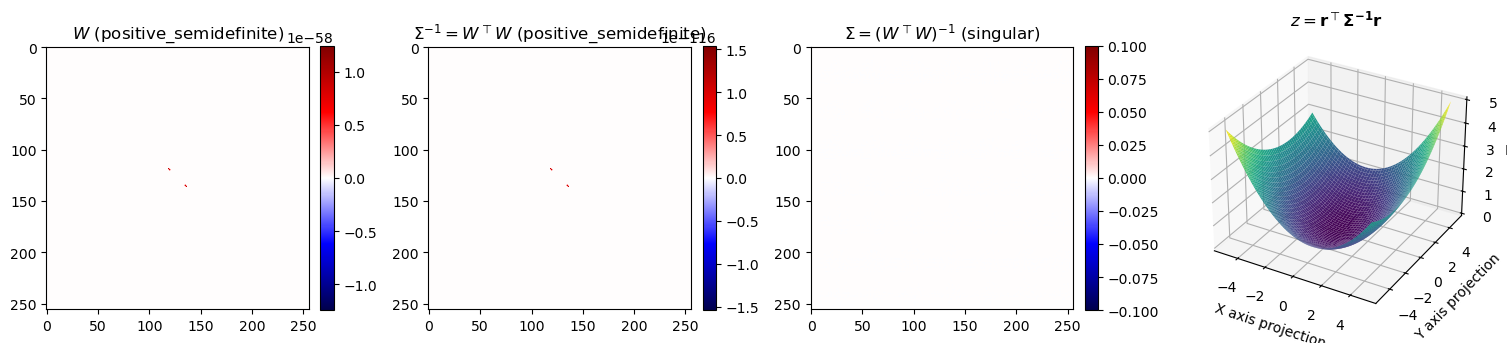

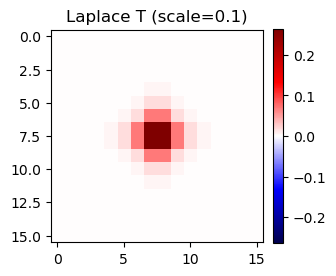

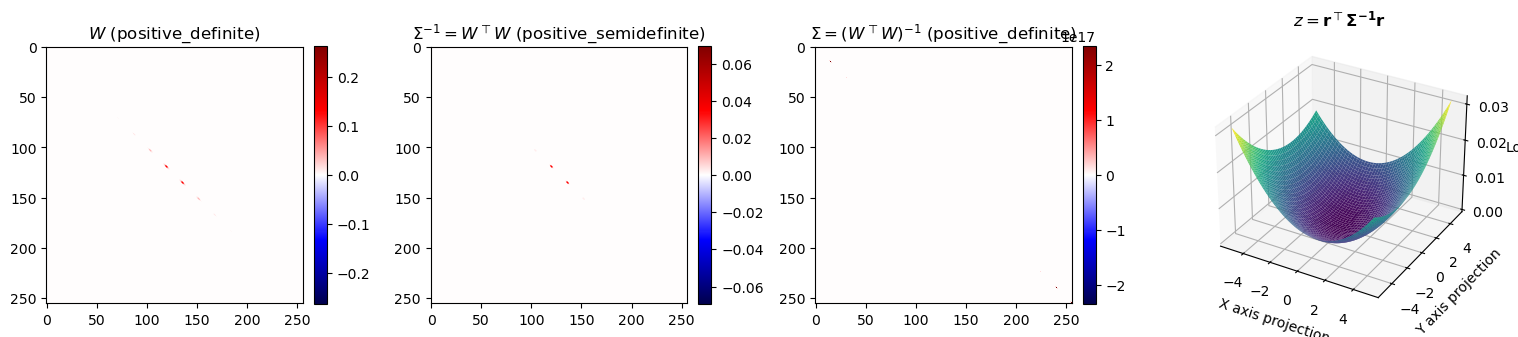

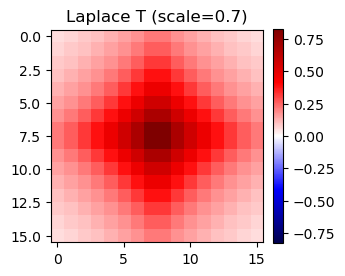

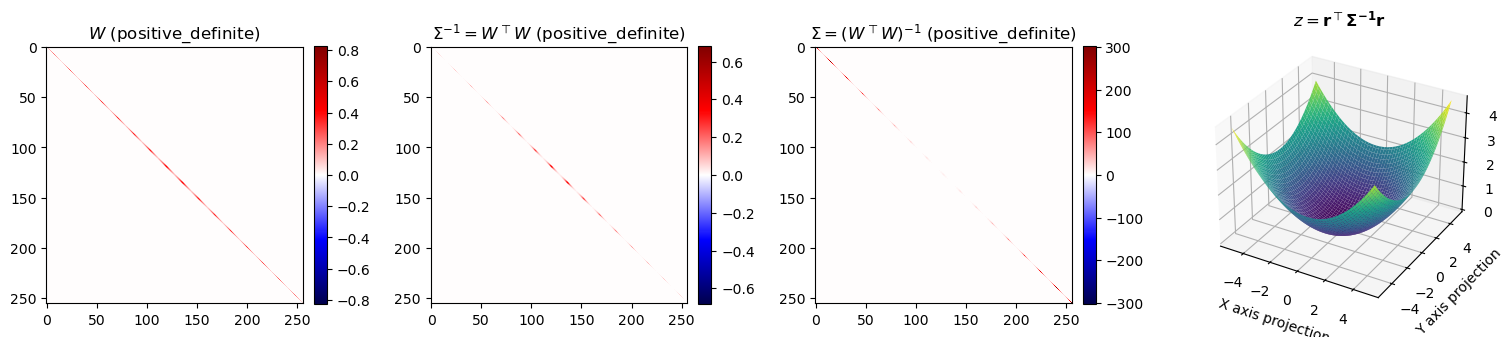

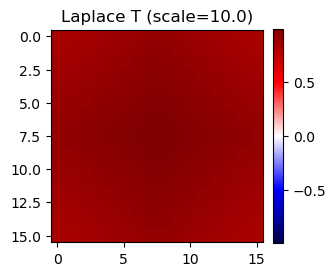

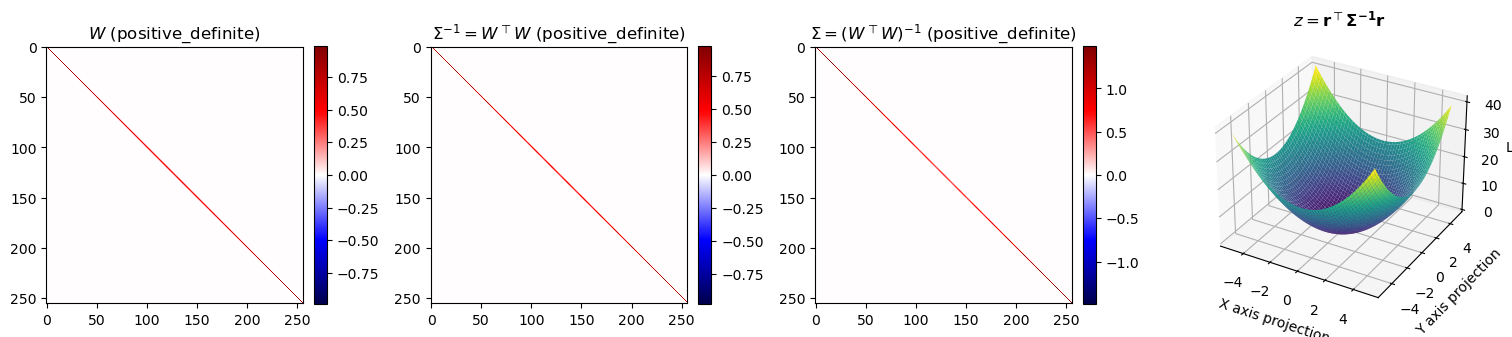

In [25]:
# laplace function in 2d
def laplace_penalty(size, scale=1.0):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    T = np.exp(- (np.abs(X) + np.abs(Y)) / scale)
    return T

# T is a 2D laplace function with mean 0 and scale 0.1
condition_number = []
scales = [1e-3,  0.1, 0.7, 10.]
for scale in scales:
    T = laplace_penalty(int(np.sqrt(n)), scale=scale)

    fig, ax = plt.subplots(1, 1, figsize=(3,3))
    plot2d(T, ax=ax,title=f"Laplace T (scale={scale})")

    W = get_W_from_T(T)
    Sinv = get_sigma_inv_from_W(W)
    condition_number.append(np.linalg.cond(Sinv))
    plot_example(W, dir_x, dir_y)

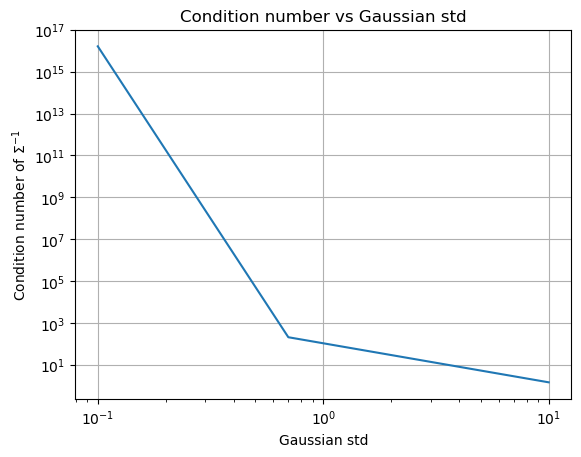

In [28]:
plt.loglog(scales, condition_number)
plt.xlabel("Gaussian std")
plt.ylabel(r"Condition number of $\Sigma^{-1}$")
plt.title("Condition number vs Gaussian std")
plt.grid()
plt.show()


This analysis is consistent with emperical observations where narrower penalty functions lead to undesirable outcomes or slow convergences.

The condition numbers of $\mathbf \Sigma^{-1}$ are stated here for curiosity. Since its inverse, $\mathbf \Sigma$, does not influence the global solution $\mathbf v = \mathbf \delta$, it may not have an impact on the stability of the loss.



## Curvature in $\mathbf \theta$

From the chain rule in column-vector gradients we have that:

$$
\nabla_{\!\boldsymbol\theta}\mathcal L_w
= \Big(\frac{\partial \mathbf v}{\partial \mathbf \theta}\Big)^{\!\top}
\nabla_{\!\mathbf v}\mathcal L_w.
$$


From previous derivations (sections *The Wiener Filter* and *Curvature in $\mathbf v$*) we have: 

$$
\nabla_{\!\mathbf v}\mathcal L_w = \boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta),
$$

and 

$$
\frac{\partial \mathbf v}{\partial \mathbf \theta} = (\mathbf Y^\top \mathbf Y)^{-1}\mathbf Y \, \mathbf J_{\mathbf x, \, \mathbf \theta},
$$

which we use to expand the chain rule:

$$
\boxed{\;
\nabla_{\!\boldsymbol\theta}\mathcal L_w
= \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\, \mathbf Y^\top\,(\mathbf Y^\top \mathbf Y)^{-1}\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta), 
\;}
$$

where we use the fact that $\mathbf Y^\top \mathbf Y$ is always symmetric, therefore $(\mathbf Y^\top \mathbf Y)^{-T} = (\mathbf Y^\top \mathbf Y)^{-1}$, and the Jacobian (defined previously) is the first derivative matrix of the input signal $\mathbf x$ with respect to model parameters $\mathbf \theta$.

We see that the first derivative is not defined when either $\mathbf Y^\top \mathbf Y$ or $\boldsymbol\Sigma$ are not positive definite (their inverses don't exist) and is unstable when their condition numbers are high.

In the section *Curvature in $\mathbf v$* we established that a wide penalty function leads to stable covariance matrices, which are positive definite and well-conditioned. The conditioning of $\mathbf Y^\top \mathbf Y$ is explored later.

We continue by letting

$$
\mathbf B \coloneqq (\mathbf Y^\top \mathbf Y)^{-1}\mathbf Y,
$$

and rewrite the first derivative as:

$$
\nabla_{\!\boldsymbol\theta}\mathcal L_w
= \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf B^\top\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta).
$$

Differentiating again with respect to $\mathbf \theta$ we have:

$$
\nabla^2_{\!\boldsymbol\theta}\mathcal L_w
= \frac{\partial}{\partial \mathbf \theta} \Big( \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf B^\top\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta) \Big ),
$$

and per chain rule:

$$
\nabla^2_{\!\boldsymbol\theta}\mathcal L_w
= \mathbf H_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf B^\top\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta) \,\,
    + \,\, \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf B^\top\,\boldsymbol\Sigma^{-1} \, \frac{\partial \mathbf v}{\partial \mathbf \theta},  
$$

which is expanded to:

$$
\nabla^2_{\!\boldsymbol\theta}\mathcal L_w
= \underbrace{\mathbf H_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf B^\top\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta)}_{\text{higher-order curvature terms}}
     \,\, + \,\, 
     \underbrace{\mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf B^\top\,\boldsymbol\Sigma^{-1} \mathbf B \, \mathbf J_{\mathbf x,\boldsymbol\theta}}_{\text{Gauss-Newton term}}
$$


Collectively, this equation provides the full curvature of the optimisation landscape of $\mathcal L_w$ with respect to $\mathbf \theta$ for a given $\mathbf v$.

The first term represents the higher order curvature and vanishes if $\mathbf x$ is a linear (affine) in $\mathbf \theta$. This is often ***not*** the case in neural networks.

The second term:
- is the Gauss–Newton term;
- is the curvature contribution independent of the residual;
- is the only contributor when $\mathbf v = \mathbf \delta$, and therefore is a representation of the curvature of the error surface around the global minimum;
- is the convex quadratic approximation (first order) to the loss curvature near the current point;
- measures how sensitive the residuals $\mathbf r = \mathbf v - \mathbf \delta$ are to perturbations in $\mathbf \theta$

For tractability and interpretability, we approximate the second derivative purely as the Gauss-Newton term:
$$
\nabla^2_{\!\boldsymbol\theta}\mathcal L_w
\approx \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf B^\top\,\boldsymbol\Sigma^{-1} \mathbf B \, \mathbf J_{\mathbf x,\boldsymbol\theta}, 
$$

and in full form:
$$
\boxed{\;
\nabla^2_{\!\boldsymbol\theta}\mathcal L_w
\approx \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\, \mathbf Y^\top\,(\mathbf Y^\top \mathbf Y)^{-1} \,\boldsymbol\Sigma^{-1} (\mathbf Y^\top \mathbf Y)^{-1}\mathbf Y \, \mathbf J_{\mathbf x,\boldsymbol\theta}, 
\;}
$$

which we use to make the sensitivity and curvature analysis described above.



### Hessian $\nabla^2_{\!\boldsymbol\theta}\mathcal L_w$ Analysis

UNFINISHED

In [ ]:
import torch

# Initialise simple neural network  model without activation functions (linear)
model = torch.nn.Sequential(
    torch.nn.Linear(n, n)
)

# create vector y and infer x from model
y = torch.randn(1, n)
x = model(y)



RuntimeError: grad can be implicitly created only for scalar outputs

### Conditioning of $\mathbf Y^\top \mathbf Y$ 

UNFINISHED

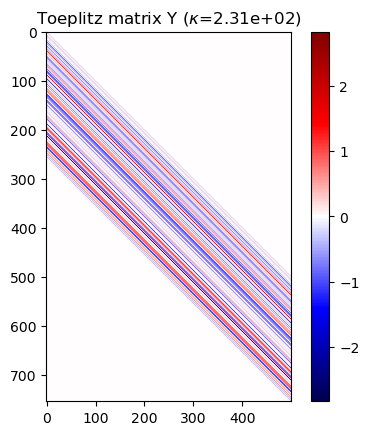

In [ ]:
from scipy.signal import convolve
from scipy.linalg import convolution_matrix

y = np.random.randn(n)
# y = np.zeros(n)
# y[np.random.choice(n, n//2, replace=False)] = 1.0  # box function
x = np.random.randn(500)

Y = convolution_matrix(y, len(x))

# check that Yx is equivalent to convolving y with x
Yx = Y @ x
yx = convolve(y, x, mode='full')
assert np.allclose(Yx, yx)

condition_number = np.linalg.cond(Y.T @ Y)

plot2d(Y, title=r"Toeplitz matrix Y ($\kappa$=" + f"{condition_number:.2e})")


<!-- **Definitions**
- Residual: $\mathbf r = \mathbf v - \boldsymbol\delta$
- Loss: $\displaystyle \mathcal L_w = \tfrac12\, \mathbf r^\top \boldsymbol\Sigma^{-1}\mathbf r$
- Filter (linear in $\mathbf x$, with $\mathbf Y$ fixed by $\mathbf y$):
  $$
  \mathbf v = \mathbf H\,\mathbf x,\qquad 
  \mathbf H \;\coloneqq\; (\mathbf Y^\top \mathbf Y)^{-1}\mathbf Y
  $$
- Model signal: $\mathbf x=\mathbf x_{\boldsymbol\theta}$

Because only the symmetric part of $\boldsymbol\Sigma^{-1}$ contributes in a quadratic form, define
$$
\boldsymbol\Sigma^{-1} \;\coloneqq\; \tfrac12\!\left(\boldsymbol\Sigma^{-1} + \boldsymbol\Sigma^{-\top}\right)
\quad\text{(note: if $\boldsymbol\Sigma^{-1}$ is symmetric, then $\boldsymbol\Sigma^{-1}=\boldsymbol\Sigma^{-1}$).}
$$

### Gradients along the chain
1) Gradient w.r.t. $\mathbf v$ (discussed above):
$$
\frac{\partial \mathcal L_w}{\partial \mathbf v}
= \boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta)
= \boldsymbol\Sigma^{-1}\,\mathbf r.
$$

2) Jacobian of $\mathbf v$ w.r.t. $\mathbf x$ (linearity):
$$
\frac{\partial \mathbf v}{\partial \mathbf x} = \mathbf H.
$$

3) Jacobian of $\mathbf x$ w.r.t. $\boldsymbol\theta$:
$$
\mathbf J_{\mathbf x,\boldsymbol\theta}\;\coloneqq\; \frac{\partial \mathbf x}{\partial \boldsymbol\theta}.
$$

### Chain rule
$$

\nabla_{\!\boldsymbol\theta}\mathcal L_w
= \Big(\frac{\partial \mathbf x}{\partial \boldsymbol\theta}\Big)^{\!\top}
\Big(\frac{\partial \mathbf v}{\partial \mathbf x}\Big)^{\!\top}
\nabla_{\!\mathbf v}\mathcal L_w

$$
then
$$
\boxed{\;
\nabla_{\!\boldsymbol\theta}\mathcal L_w
= \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\,\mathbf H^{\!\top}\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta)
\;}
$$

Plugging $\mathbf H$ explicitly and using that $\mathbf Y^\top\mathbf Y$ is symmetric (so $(\mathbf Y^\top\mathbf Y)^{-T}=(\mathbf Y^\top\mathbf Y)^{-1}$):
$$
\boxed{\;
\nabla_{\!\boldsymbol\theta}\mathcal L_w
= \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\, \mathbf Y^\top\,(\mathbf Y^\top \mathbf Y)^{-1}\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta)
\;}
$$

If $\boldsymbol\Sigma^{-1}$ is symmetric (the usual case):
$$
\boxed{\;
\nabla_{\!\boldsymbol\theta}\mathcal L_w
= \mathbf J_{\mathbf x,\boldsymbol\theta}^{\!\top}\, \mathbf Y^\top\,(\mathbf Y^\top \mathbf Y)^{-1}\,\boldsymbol\Sigma^{-1}\,(\mathbf v-\boldsymbol\delta)
\;}
$$
with $\mathbf v = (\mathbf Y^\top \mathbf Y)^{-1}\mathbf Y\,\mathbf x_{\boldsymbol\theta}$. -->